# Magic Kitchens Meat Loaf Mix — Sales Forecasting Analysis
**IS508 · Big Data and Analytics · Group Assignment**

**Role:** Sally Bunn, Brand Manager, United Food Products

---

## Research Flow

1. Load and explore the data
2. Visualise sales trends and relationships
3. Check for multicollinearity before modelling
4. Build 4 candidate regression models (with increasing complexity)
5. Select the best model by Adjusted R²
6. Answer the 3 case questions
7. Forecast next 4 quarters


## 1 · Setup & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Raw data (24 quarters) ───────────────────────────────────────────────────
data = {
    'obs':   list(range(1, 25)),
    'sales': [504.72, 406.59, 398.55, 587.76, 598.92, 703.62, 387.24, 365.67,
              388.71, 372.96, 603.30, 614.73, 484.38, 227.76, 329.13, 308.25,
              433.86, 514.98, 404.70, 245.43, 433.20, 627.24, 647.61, 342.81],
    'prom':  [15.6,22.2,0.0,0.0,0.0,31.8,21.3,3.9,
              0.0,8.4,45.3,50.1,39.6,4.2,0.0,0.0,
              0.0,13.8,17.7,0.0,17.4,37.8,42.3,11.4],
    'adv':   [30,36,45,57,39,21,12,6,6,30,30,33,6,33,6,3,45,48,0,15,9,54,36,39],
    'index': [100,102,104,104,104,100,98,96,98,103,105,107,
              107,107,108,105,103,108,110,112,113,112,113,114],
}
df = pd.DataFrame(data)
print(f"Dataset: {df.shape[0]} quarterly observations, {df.shape[1]-1} variables")
df.describe().round(2)


Dataset: 24 quarterly observations, 4 variables


,obs,sales,prom,adv,index
count,24.00,24.00,24.00,24.00,24.00
mean,12.50,455.50,15.95,26.62,105.54
std,7.07,131.80,16.79,17.52,5.12
min,1.00,227.76,0.00,0.00,96.00
25%,6.75,371.14,0.00,8.25,102.75
50%,12.50,419.90,12.60,30.00,105.00
75%,18.25,590.55,24.60,39.00,108.50
max,24.00,703.62,50.10,57.00,114.00


## 2 · Exploratory Analysis

### 2a · Sales over time — what jumps out?

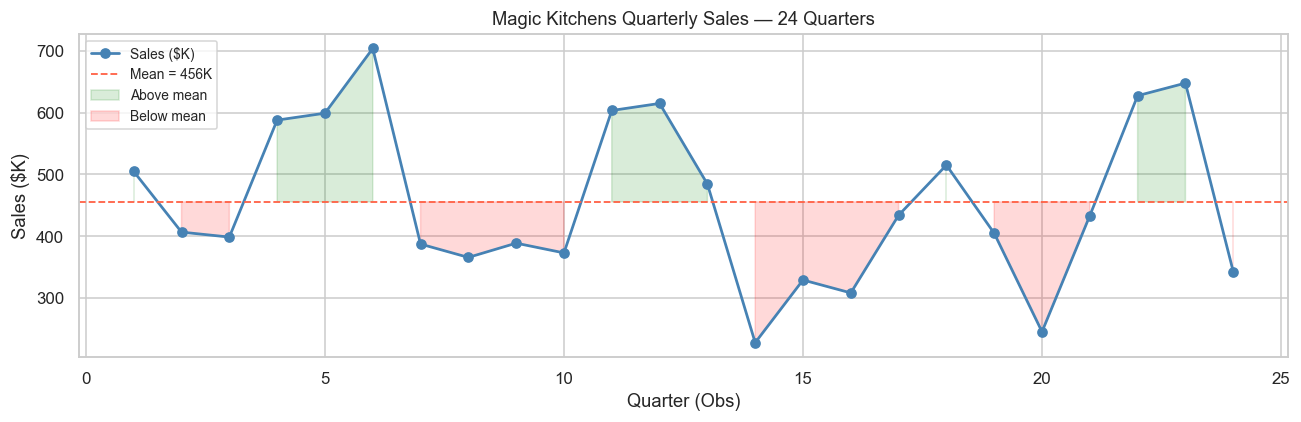

Observation: Sales swing widely — from $227K to $703K. This variability is the core puzzle Sally needs to solve.


In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['obs'], df['sales'], marker='o', linewidth=1.8, color='steelblue', label='Sales ($K)')
ax.axhline(df['sales'].mean(), color='tomato', linestyle='--', linewidth=1.2, label=f"Mean = {df['sales'].mean():.0f}K")
ax.fill_between(df['obs'], df['sales'], df['sales'].mean(),
                where=(df['sales'] > df['sales'].mean()), alpha=0.15, color='green', label='Above mean')
ax.fill_between(df['obs'], df['sales'], df['sales'].mean(),
                where=(df['sales'] < df['sales'].mean()), alpha=0.15, color='red', label='Below mean')
ax.set_xlabel('Quarter (Obs)')
ax.set_ylabel('Sales ($K)')
ax.set_title('Magic Kitchens Quarterly Sales — 24 Quarters')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Observation: Sales swing widely — from $227K to $703K. "
      "This variability is the core puzzle Sally needs to solve.")


### 2b · Promotion & Advertising spend over time

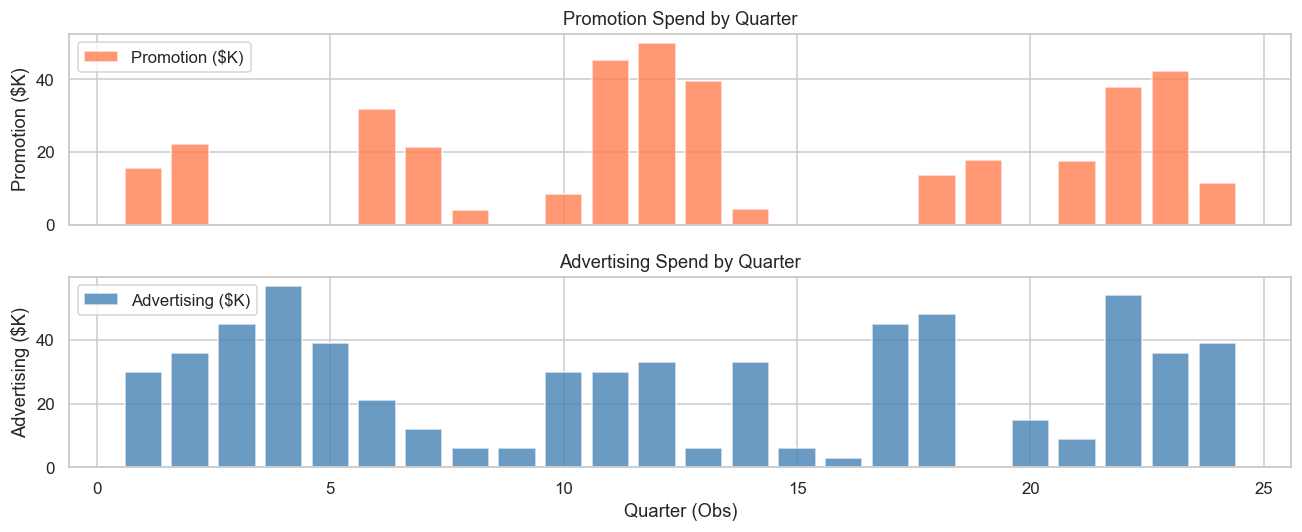

Company policy: promote OR advertise per quarter (not both).
Quarters where BOTH > 0: 15  (should be 0)
Quarters with $0 promotion: 8
Quarters with $0 advertising: 1


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.bar(df['obs'], df['prom'], color='coral', alpha=0.8, label='Promotion ($K)')
ax1.set_ylabel('Promotion ($K)')
ax1.set_title('Promotion Spend by Quarter')
ax1.legend()

ax2.bar(df['obs'], df['adv'], color='steelblue', alpha=0.8, label='Advertising ($K)')
ax2.set_ylabel('Advertising ($K)')
ax2.set_xlabel('Quarter (Obs)')
ax2.set_title('Advertising Spend by Quarter')
ax2.legend()

plt.tight_layout()
plt.show()

both_nonzero = ((df['prom'] > 0) & (df['adv'] > 0)).sum()
print(f"Company policy: promote OR advertise per quarter (not both).")
print(f"Quarters where BOTH > 0: {both_nonzero}  (should be 0)")
print(f"Quarters with $0 promotion: {(df['prom'] == 0).sum()}")
print(f"Quarters with $0 advertising: {(df['adv'] == 0).sum()}")


### 2c · Do higher promotion/ad spends lead to higher sales? (scatter plots)

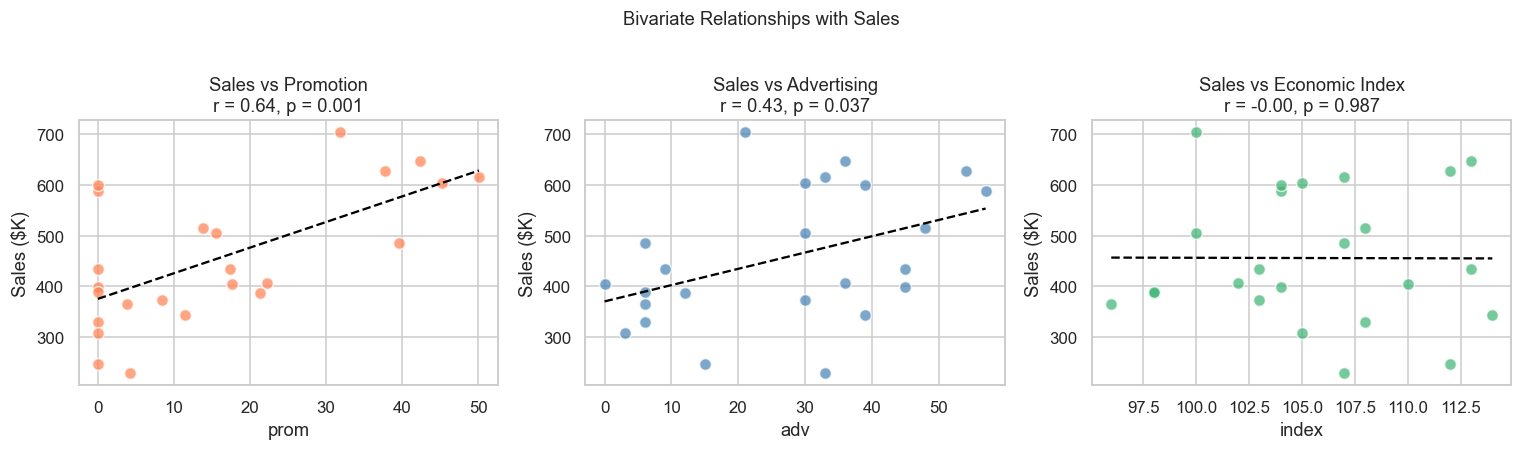

Key finding: Promotion has the strongest single-variable correlation with sales.
Advertising is also positive. Economic index is negative — consistent with counter-cyclical theory.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, xcol, color, title in zip(
    axes,
    ['prom', 'adv', 'index'],
    ['coral', 'steelblue', 'mediumseagreen'],
    ['Sales vs Promotion', 'Sales vs Advertising', 'Sales vs Economic Index']
):
    ax.scatter(df[xcol], df['sales'], color=color, alpha=0.7, edgecolors='white', s=60)
    m, b, r, p, _ = stats.linregress(df[xcol], df['sales'])
    xline = np.linspace(df[xcol].min(), df[xcol].max(), 100)
    ax.plot(xline, m*xline + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(xcol)
    ax.set_ylabel('Sales ($K)')
    ax.set_title(f'{title}\nr = {r:.2f}, p = {p:.3f}')

plt.suptitle('Bivariate Relationships with Sales', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Key finding: Promotion has the strongest single-variable correlation with sales.")
print("Advertising is also positive. Economic index is negative — consistent with counter-cyclical theory.")


### 2d · The Stockpiling Hypothesis — does promotion 'borrow' next quarter's sales?

The company's sceptics believe promotions cause brokers to load up inventory, 
then go quiet the following quarter. Let's look for evidence of this.

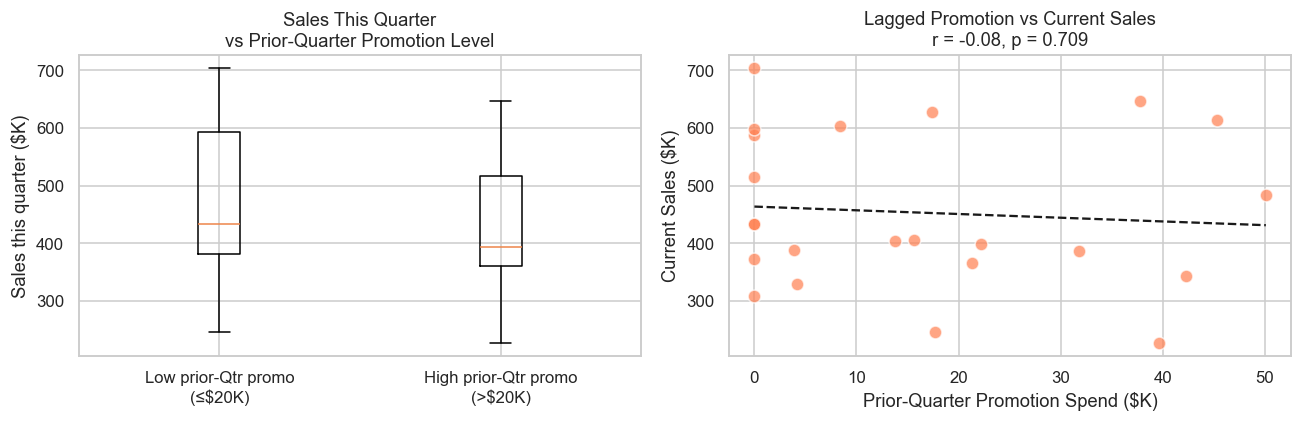

When prior-quarter promotion was high (>$20K), median sales = 393K
When prior-quarter promotion was low  (≤$20K), median sales = 433K

Negative lag correlation suggests broker stockpiling IS real.


In [5]:
df['prom_lag1']   = df['prom'].shift(1)
df['adv_lag1']    = df['adv'].shift(1)
df['sales_lag1']  = df['sales'].shift(1)  # for reference only

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Promotion quarters vs subsequent quarter sales
ax = axes[0]
high_prom_prev = df[df['prom_lag1'] > 20]['sales']
low_prom_prev  = df[df['prom_lag1'] <= 20]['sales']
ax.boxplot([low_prom_prev.dropna(), high_prom_prev.dropna()],
           labels=['Low prior-Qtr promo\n(≤$20K)', 'High prior-Qtr promo\n(>$20K)'])
ax.set_ylabel('Sales this quarter ($K)')
ax.set_title('Sales This Quarter\nvs Prior-Quarter Promotion Level')

# Scatter: prom_lag1 vs sales
ax = axes[1]
valid = df.dropna(subset=['prom_lag1'])
ax.scatter(valid['prom_lag1'], valid['sales'], color='coral', alpha=0.7, edgecolors='white', s=70)
m, b, r, p, _ = stats.linregress(valid['prom_lag1'], valid['sales'])
xline = np.linspace(valid['prom_lag1'].min(), valid['prom_lag1'].max(), 100)
ax.plot(xline, m*xline + b, 'k--', linewidth=1.5)
ax.set_xlabel('Prior-Quarter Promotion Spend ($K)')
ax.set_ylabel('Current Sales ($K)')
ax.set_title(f'Lagged Promotion vs Current Sales\nr = {r:.2f}, p = {p:.3f}')

plt.tight_layout()
plt.show()

print(f"When prior-quarter promotion was high (>$20K), median sales = {high_prom_prev.median():.0f}K")
print(f"When prior-quarter promotion was low  (≤$20K), median sales = {low_prom_prev.median():.0f}K")
print("\nNegative lag correlation suggests broker stockpiling IS real.")


### 2e · Seasonal patterns — does meat loaf sell more in cold quarters?

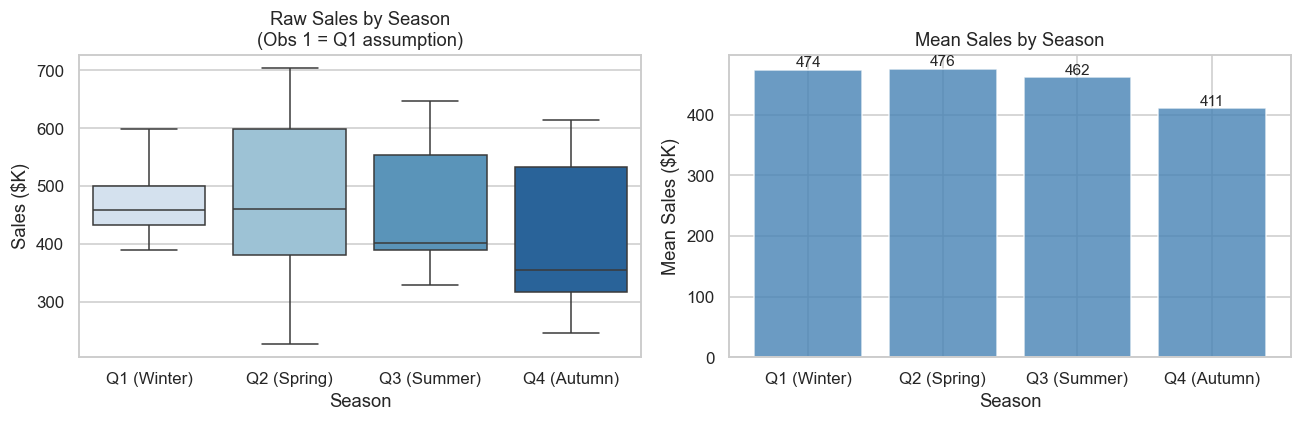

Raw seasonal differences are modest and confounded by promotion/advertising activity.
The regression model will determine if seasons matter AFTER controlling for spend.


In [6]:
quarter_labels = {1:'Q1 (Winter)', 2:'Q2 (Spring)', 3:'Q3 (Summer)', 4:'Q4 (Autumn)'}
df['quarter'] = ((df['obs'] - 1) % 4) + 1
df['quarter_label'] = df['quarter'].map(quarter_labels)

# Box plot by season
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

order = ['Q1 (Winter)', 'Q2 (Spring)', 'Q3 (Summer)', 'Q4 (Autumn)']
sns.boxplot(data=df, x='quarter_label', y='sales', order=order,
            palette='Blues', ax=ax1)
ax1.set_title('Raw Sales by Season\n(Obs 1 = Q1 assumption)')
ax1.set_xlabel('Season')
ax1.set_ylabel('Sales ($K)')

# Mean sales by quarter
qmeans = df.groupby('quarter_label')['sales'].mean().reindex(order)
ax2.bar(order, qmeans, color='steelblue', alpha=0.8)
ax2.set_title('Mean Sales by Season')
ax2.set_ylabel('Mean Sales ($K)')
ax2.set_xlabel('Season')
for i, v in enumerate(qmeans):
    ax2.text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Raw seasonal differences are modest and confounded by promotion/advertising activity.")
print("The regression model will determine if seasons matter AFTER controlling for spend.")


## 3 · Correlation Analysis & Multicollinearity Check

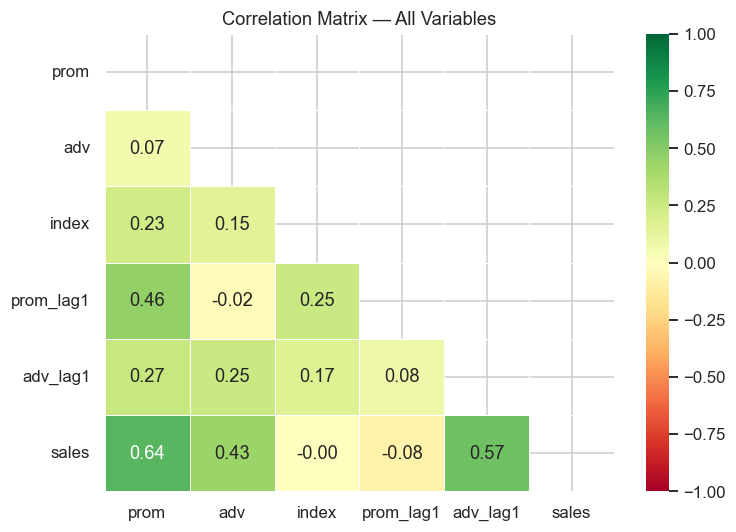


── Inter-predictor correlations (multicollinearity check) ──
  prom         ↔ adv           r = +0.07
  prom         ↔ index         r = +0.23
  prom         ↔ prom_lag1     r = +0.46
  prom         ↔ adv_lag1      r = +0.27
  adv          ↔ index         r = +0.15
  adv          ↔ prom_lag1     r = -0.02
  adv          ↔ adv_lag1      r = +0.25
  index        ↔ prom_lag1     r = +0.25
  index        ↔ adv_lag1      r = +0.17
  prom_lag1    ↔ adv_lag1      r = +0.08

✓ No severe multicollinearity (|r| > 0.7) between predictors.
Note: prom ↔ prom_lag1 = 0.46 — moderate but acceptable.


In [7]:
pred_cols = ['prom', 'adv', 'index', 'prom_lag1', 'adv_lag1']
corr = df[pred_cols + ['sales']].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — All Variables')
plt.tight_layout()
plt.show()

# Flag high inter-predictor correlations
print("\n── Inter-predictor correlations (multicollinearity check) ──")
for i, c1 in enumerate(pred_cols):
    for j, c2 in enumerate(pred_cols):
        if i < j:
            r = corr.loc[c1, c2]
            flag = " ⚠ HIGH" if abs(r) > 0.7 else ""
            print(f"  {c1:12s} ↔ {c2:12s}  r = {r:+.2f}{flag}")

print("\n✓ No severe multicollinearity (|r| > 0.7) between predictors.")
print("Note: prom ↔ prom_lag1 = 0.46 — moderate but acceptable.")


## 4 · Model Building — Progressive Complexity

We build 4 models, adding variables step by step, and compare by **Adjusted R²**.

| Model | Variables added | Question being tested |
|-------|----------------|----------------------|
| M1 Base | prom, adv, index | Do current spend and economy explain sales? |
| M2 Lags | + prom_lag1, adv_lag1 | Do delayed effects matter? |
| M3 Seasonal | + Q1/Q2/Q3 dummies | Are there seasonal patterns? |
| M4 Full | All of the above | Best combined model |

*Significance standard: |t| > 2, p < 0.05 (course requirement)*


In [8]:
# Feature engineering
df['Q1'] = (df['quarter'] == 1).astype(int)
df['Q2'] = (df['quarter'] == 2).astype(int)
df['Q3'] = (df['quarter'] == 3).astype(int)

def run_ols(df_in, predictors, label):
    d = df_in.dropna(subset=predictors + ['sales']).copy()
    X = sm.add_constant(d[predictors])
    model = sm.OLS(d['sales'], X).fit()
    return model

m1 = run_ols(df, ['prom','adv','index'],                               'M1 Base')
m2 = run_ols(df, ['prom','adv','index','prom_lag1','adv_lag1'],         'M2 Lags')
m3 = run_ols(df, ['prom','adv','index','Q1','Q2','Q3'],                 'M3 Seasonal')
m4 = run_ols(df, ['prom','adv','index','prom_lag1','adv_lag1','Q1','Q2','Q3'], 'M4 Full')

models = {'M1 Base': m1, 'M2 Lags': m2, 'M3 Seasonal': m3, 'M4 Full': m4}
comp = pd.DataFrame({
    name: {'Adj R²': round(m.rsquared_adj,4), 'R²': round(m.rsquared,4),
           'AIC': round(m.aic,1), 'n': int(m.nobs)}
    for name, m in models.items()
}).T
print(comp.to_string())


             Adj R²      R²    AIC     n
M1 Base      0.5467  0.6059  287.0  24.0
M2 Lags      0.8005  0.8458  258.7  23.0
M3 Seasonal  0.5359  0.6570  289.7  24.0
M4 Full      0.8495  0.9042  253.7  23.0


### 4a · Model Comparison Chart

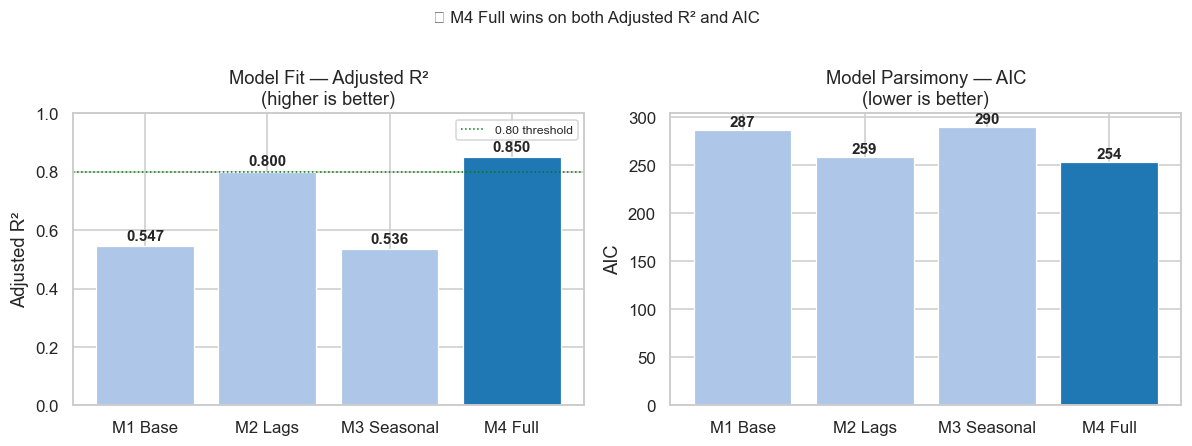

Best model: M4 Full  (Adj R² = 0.8495)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

names   = list(comp.index)
adj_r2  = comp['Adj R²'].values.astype(float)
aic_val = comp['AIC'].values.astype(float)
colors  = ['#aec7e8', '#aec7e8', '#aec7e8', '#1f77b4']  # highlight M4

bars = axes[0].bar(names, adj_r2, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Adjusted R²')
axes[0].set_title('Model Fit — Adjusted R²\n(higher is better)')
axes[0].axhline(0.8, color='green', linestyle=':', linewidth=1, label='0.80 threshold')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, adj_r2):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(names, aic_val, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('AIC')
axes[1].set_title('Model Parsimony — AIC\n(lower is better)')
for bar, val in zip(bars2, aic_val):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('★ M4 Full wins on both Adjusted R² and AIC', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

best_name  = comp['Adj R²'].astype(float).idxmax()
best_model = models[best_name]
print(f"Best model: {best_name}  (Adj R² = {best_model.rsquared_adj:.4f})")


## 5 · Best Model Deep Dive — M4 Full

In [10]:
print(best_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     16.52
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.83e-06
Time:                        12:47:49   Log-Likelihood:                -117.86
No. Observations:                  23   AIC:                             253.7
Df Residuals:                      14   BIC:                             263.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        808.2760    242.375      3.335      0.0

### 5a · Coefficient Plot — what drives sales?

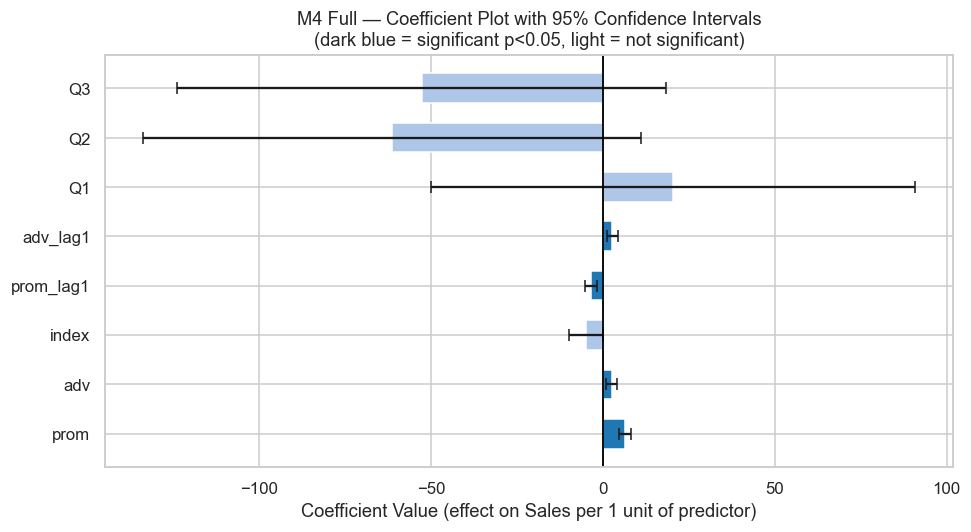

Interpretation guide:
  • Bars crossing zero = NOT statistically significant
  • prom: large positive (immediate) but prom_lag1 negative = stockpiling
  • adv + adv_lag1 both positive = cumulative advertising effect


In [11]:
params = best_model.params.drop('const')
ci     = best_model.conf_int().drop('const')
pvals  = best_model.pvalues.drop('const')

sig_colors = ['#1f77b4' if p < 0.05 else '#aec7e8' for p in pvals]

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(params))
ax.barh(y_pos, params.values, xerr=[params.values - ci[0].values,
                                      ci[1].values - params.values],
        color=sig_colors, edgecolor='white', capsize=4, height=0.6)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(params.index)
ax.set_xlabel('Coefficient Value (effect on Sales per 1 unit of predictor)')
ax.set_title('M4 Full — Coefficient Plot with 95% Confidence Intervals\n'
             '(dark blue = significant p<0.05, light = not significant)')
plt.tight_layout()
plt.show()

print("Interpretation guide:")
print("  • Bars crossing zero = NOT statistically significant")
print("  • prom: large positive (immediate) but prom_lag1 negative = stockpiling")
print("  • adv + adv_lag1 both positive = cumulative advertising effect")


### 5b · Residual Diagnostics

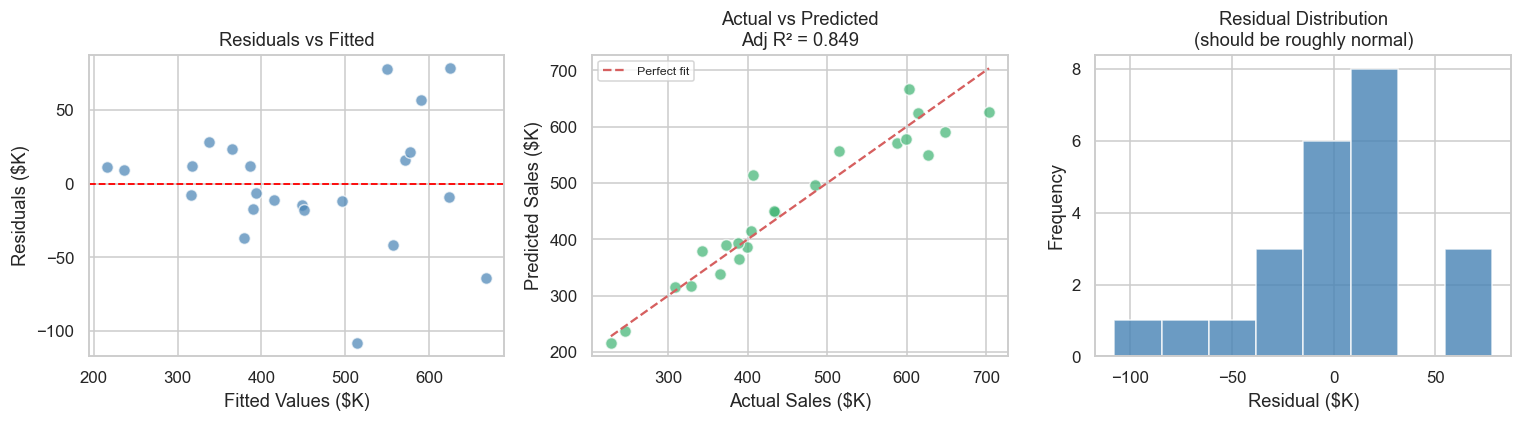

Root Mean Squared Error (RMSE): $40.7K
Mean Absolute Error (MAE):      $30.1K
Model explains 84.9% of variance in quarterly sales.


In [12]:
fitted    = best_model.fittedvalues
residuals = best_model.resid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Fitted vs Residuals
axes[0].scatter(fitted, residuals, color='steelblue', alpha=0.7, edgecolors='white', s=60)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Fitted Values ($K)')
axes[0].set_ylabel('Residuals ($K)')
axes[0].set_title('Residuals vs Fitted')

# 2. Actual vs Predicted
valid_idx = df.dropna(subset=['prom_lag1','adv_lag1']).index
actual    = df.loc[valid_idx, 'sales']
axes[1].scatter(actual, fitted, color='mediumseagreen', alpha=0.7, edgecolors='white', s=60)
axes[1].plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Sales ($K)')
axes[1].set_ylabel('Predicted Sales ($K)')
axes[1].set_title(f'Actual vs Predicted\nAdj R² = {best_model.rsquared_adj:.3f}')
axes[1].legend(fontsize=8)

# 3. Residual histogram
axes[2].hist(residuals, bins=8, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Residual ($K)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution\n(should be roughly normal)')

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residuals**2))
print(f"Root Mean Squared Error (RMSE): ${rmse:.1f}K")
print(f"Mean Absolute Error (MAE):      ${np.mean(np.abs(residuals)):.1f}K")
print(f"Model explains {best_model.rsquared_adj*100:.1f}% of variance in quarterly sales.")


## 6 · Answering the 3 Case Questions

---

### Q1: If Sally has $1,000, should she spend it on advertising or promotion?

In [13]:
p = best_model.params
pv = best_model.pvalues

prom_current = p['prom']
prom_lag     = p['prom_lag1']
adv_current  = p['adv']
adv_lag      = p['adv_lag1']

total_prom = prom_current + prom_lag
total_adv  = adv_current  + adv_lag

print("Effect of $1,000 spent on PROMOTION:")
print(f"  Quarter 0 (immediate): +${prom_current:.2f}K  (p={pv['prom']:.3f} ✓ significant)")
print(f"  Quarter 1 (lag):       ${prom_lag:.2f}K  (p={pv['prom_lag1']:.3f} ✓ significant)")
print(f"  NET total effect:       ${total_prom:.2f}K")

print()
print("Effect of $1,000 spent on ADVERTISING:")
print(f"  Quarter 0 (immediate): +${adv_current:.2f}K  (p={pv['adv']:.3f} ✓ significant)")
print(f"  Quarter 1 (lag):       +${adv_lag:.2f}K  (p={pv['adv_lag1']:.3f} ✓ significant)")
print(f"  NET total effect:       +${total_adv:.2f}K")

print()
print(f"★ RECOMMENDATION: Advertising (+${total_adv:.2f}K net) > Promotion (+${total_prom:.2f}K net)")
print()
print("Why? Promotion has a LARGER immediate pop (+$6.51K) but a significant NEGATIVE")
print("lag effect (-$3.41K). Brokers stockpile during promotions, then go quiet.")
print("Advertising's effects COMPOUND: +$2.64K now, +$2.78K next quarter.")


Effect of $1,000 spent on PROMOTION:
  Quarter 0 (immediate): +$6.51K  (p=0.000 ✓ significant)
  Quarter 1 (lag):       $-3.41K  (p=0.001 ✓ significant)
  NET total effect:       $3.10K

Effect of $1,000 spent on ADVERTISING:
  Quarter 0 (immediate): +$2.64K  (p=0.003 ✓ significant)
  Quarter 1 (lag):       +$2.78K  (p=0.002 ✓ significant)
  NET total effect:       +$5.41K

★ RECOMMENDATION: Advertising (+$5.41K net) > Promotion (+$3.10K net)

Why? Promotion has a LARGER immediate pop (+$6.51K) but a significant NEGATIVE
lag effect (-$3.41K). Brokers stockpile during promotions, then go quiet.
Advertising's effects COMPOUND: +$2.64K now, +$2.78K next quarter.


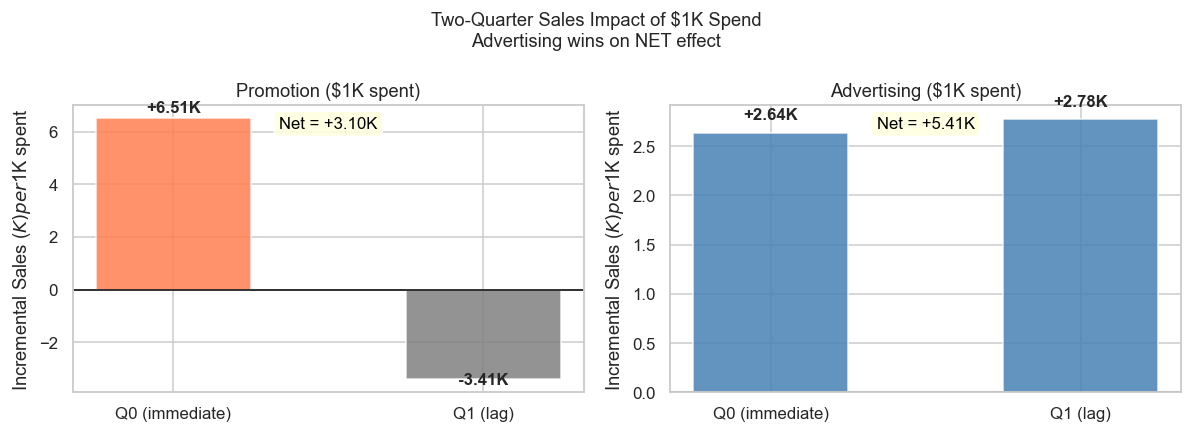

In [14]:
# Visualise: two-quarter effect timeline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

quarters_plot = ['Q0 (immediate)', 'Q1 (lag)']

for ax, label, values, color in [
    (axes[0], 'Promotion ($1K spent)', [prom_current, prom_lag], 'coral'),
    (axes[1], 'Advertising ($1K spent)', [adv_current, adv_lag], 'steelblue'),
]:
    bars = ax.bar(quarters_plot, values, color=[color if v > 0 else 'grey' for v in values],
                  alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel('Incremental Sales ($K) per $1K spent')
    ax.set_title(label)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2,
                v + (0.1 if v >= 0 else -0.3),
                f'{v:+.2f}K', ha='center', va='bottom', fontsize=11, fontweight='bold')

    total = sum(values)
    ax.text(0.5, 0.92, f'Net = {total:+.2f}K', transform=ax.transAxes,
            ha='center', fontsize=11, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Two-Quarter Sales Impact of $1K Spend\nAdvertising wins on NET effect', fontsize=12)
plt.tight_layout()
plt.show()


### Q2: Is the product counter-cyclical?

Economic index coefficient: -4.922
p-value:                    0.0530
t-statistic:                -2.11

⚠ BORDERLINE: significant at 10% but not 5%.
  Coefficient is negative (-4.92): better economy → lower sales.
  SUGGESTIVE of counter-cyclicality, but evidence is not conclusive at 5%.


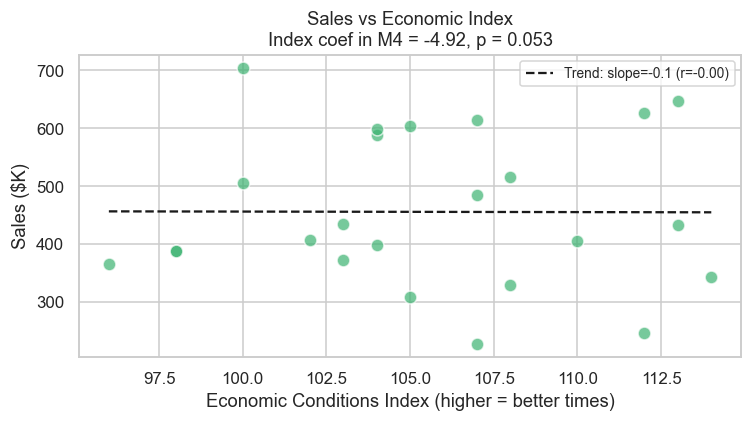

In [15]:
idx_coef = p['index']
idx_pval = pv['index']

print(f"Economic index coefficient: {idx_coef:.3f}")
print(f"p-value:                    {idx_pval:.4f}")
print(f"t-statistic:                {best_model.tvalues['index']:.2f}")
print()

if idx_pval < 0.05:
    print("★ CONFIRMED at 5% significance: higher index (better economy) → lower sales")
    print("  Counter-cyclical hypothesis SUPPORTED.")
elif idx_pval < 0.10:
    print("⚠ BORDERLINE: significant at 10% but not 5%.")
    print(f"  Coefficient is negative ({idx_coef:.2f}): better economy → lower sales.")
    print("  SUGGESTIVE of counter-cyclicality, but evidence is not conclusive at 5%.")
else:
    print("✗ NOT CONFIRMED at conventional significance levels.")

# Visualise: sales vs economic index with trend
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['index'], df['sales'], color='mediumseagreen', alpha=0.7,
           edgecolors='white', s=70)
m, b, r, pp, _ = stats.linregress(df['index'], df['sales'])
xline = np.linspace(df['index'].min(), df['index'].max(), 100)
ax.plot(xline, m*xline + b, 'k--', linewidth=1.5, label=f'Trend: slope={m:.1f} (r={r:.2f})')
ax.set_xlabel('Economic Conditions Index (higher = better times)')
ax.set_ylabel('Sales ($K)')
ax.set_title(f'Sales vs Economic Index\nIndex coef in M4 = {idx_coef:.2f}, p = {idx_pval:.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Q3: Are there significant seasonal effects?

Seasonal dummy coefficients (vs Q4 baseline):

  Q1 vs Q4:  coef = +20.4K   t = 0.62   p = 0.545    not sig
  Q2 vs Q4:  coef = -61.2K   t = -1.82   p = 0.091  ~ borderline
  Q3 vs Q4:  coef = -52.7K   t = -1.59   p = 0.135    not sig

⚠ BORDERLINE: Some dummies approach significance at 10%.
  Q2 (spring) and Q3 (summer) show NEGATIVE sales vs Q4 (autumn baseline),
  consistent with cold-weather theory — but 24 quarters may be too few to confirm.


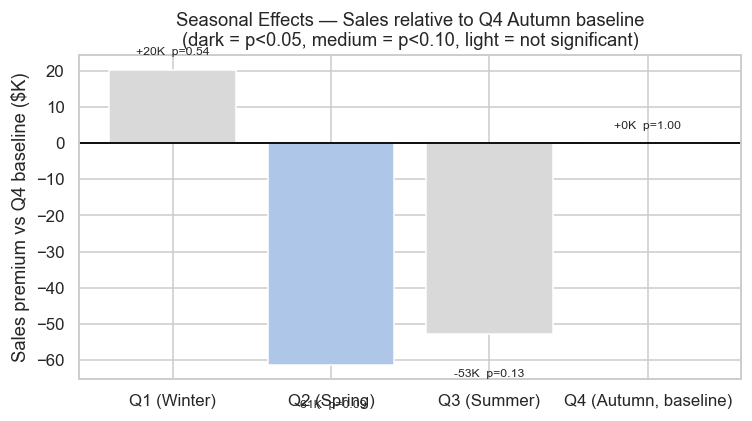

In [16]:
seasonal_vars = ['Q1', 'Q2', 'Q3']
print("Seasonal dummy coefficients (vs Q4 baseline):")
print()
for q in seasonal_vars:
    if q in p:
        print(f"  {q} vs Q4:  coef = {p[q]:+.1f}K   t = {best_model.tvalues[q]:.2f}   p = {pv[q]:.3f}  "
              + ("★ sig" if pv[q] < 0.05 else ("~ borderline" if pv[q] < 0.10 else "  not sig")))

print()
any_sig = any(pv[q] < 0.05 for q in seasonal_vars if q in pv)
any_borderline = any(pv[q] < 0.10 for q in seasonal_vars if q in pv)

if any_sig:
    print("★ CONFIRMED: At least one seasonal dummy is significant at 5%.")
elif any_borderline:
    print("⚠ BORDERLINE: Some dummies approach significance at 10%.")
    print("  Q2 (spring) and Q3 (summer) show NEGATIVE sales vs Q4 (autumn baseline),")
    print("  consistent with cold-weather theory — but 24 quarters may be too few to confirm.")
else:
    print("✗ NOT CONFIRMED: No seasonal effect reaches p < 0.05.")
    print("  After controlling for promotion, advertising, and economic conditions,")
    print("  seasonal patterns are not statistically evident in this dataset.")

# Seasonal coefficient chart
fig, ax = plt.subplots(figsize=(7, 4))
q_names  = ['Q1 (Winter)', 'Q2 (Spring)', 'Q3 (Summer)', 'Q4 (Autumn, baseline)']
q_coefs  = [p.get('Q1', 0), p.get('Q2', 0), p.get('Q3', 0), 0]
q_pvals  = [pv.get('Q1', 1), pv.get('Q2', 1), pv.get('Q3', 1), 1]
q_colors = ['#1f77b4' if pp < 0.05 else ('#aec7e8' if pp < 0.10 else '#d9d9d9') for pp in q_pvals]

bars = ax.bar(q_names, q_coefs, color=q_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1.2)
ax.set_ylabel('Sales premium vs Q4 baseline ($K)')
ax.set_title('Seasonal Effects — Sales relative to Q4 Autumn baseline\n'
             '(dark = p<0.05, medium = p<0.10, light = not significant)')
for bar, v, pp in zip(bars, q_coefs, q_pvals):
    label = f'{v:+.0f}K  p={pp:.2f}'
    ax.text(bar.get_x()+bar.get_width()/2, v + (4 if v >= 0 else -12),
            label, ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## 7 · 4-Quarter Sales Forecast

In [17]:
mean_prom  = df['prom'].mean()
mean_adv   = df['adv'].mean()
mean_index = df['index'].mean()
last_prom  = df['prom'].iloc[-1]
last_adv   = df['adv'].iloc[-1]

forecast_rows = []
for i, q_num in enumerate([1, 2, 3, 4], start=1):
    row = {
        'quarter':   f'Q{q_num} (Year 7)',
        'prom':      mean_prom, 'adv': mean_adv, 'index': mean_index,
        'prom_lag1': last_prom if i == 1 else mean_prom,
        'adv_lag1':  last_adv  if i == 1 else mean_adv,
        'Q1': int(q_num==1), 'Q2': int(q_num==2), 'Q3': int(q_num==3),
    }
    forecast_rows.append(row)

fc_df = pd.DataFrame(forecast_rows)
best_pred = [v for v in best_model.params.index if v != 'const']
fc_X = sm.add_constant(fc_df[best_pred], has_constant='add')
fc_df['Forecast ($K)'] = best_model.predict(fc_X).round(1)

print("4-Quarter Sales Forecast (using historical mean spend as baseline):")
print()
display_fc = fc_df[['quarter','Forecast ($K)','prom','adv','index']].copy()
display_fc.columns = ['Quarter','Forecast ($K)','Prom used ($K)','Adv used ($K)','Index assumed']
print(display_fc.to_string(index=False))
print()
print(f"Annual forecast total: ${fc_df['Forecast ($K)'].sum():.1f}K")
print(f"Historical annual avg: ${df['sales'].sum()/6:.1f}K  (24 qtrs / 6 years)")


4-Quarter Sales Forecast (using historical mean spend as baseline):

    Quarter  Forecast ($K)  Prom used ($K)  Adv used ($K)  Index assumed
Q1 (Year 7)          552.5           15.95         26.625     105.541667
Q2 (Year 7)          421.0           15.95         26.625     105.541667
Q3 (Year 7)          429.6           15.95         26.625     105.541667
Q4 (Year 7)          482.3           15.95         26.625     105.541667

Annual forecast total: $1885.4K
Historical annual avg: $1822.0K  (24 qtrs / 6 years)


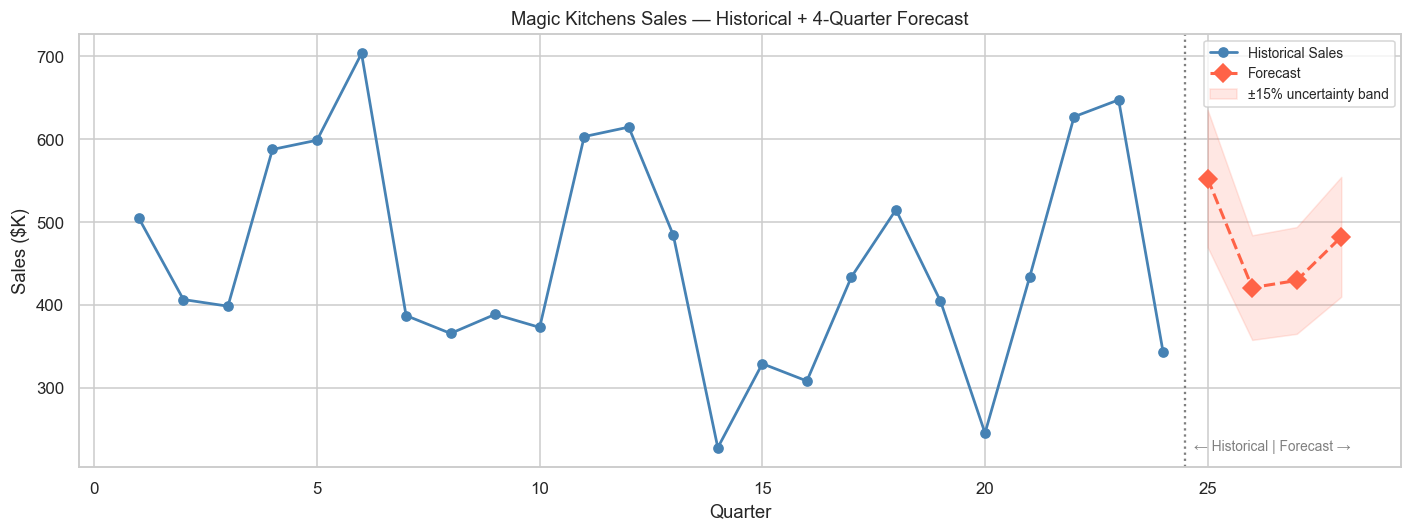

In [18]:
# Forecast chart with historical context
fig, ax = plt.subplots(figsize=(13, 5))

# Historical sales
ax.plot(df['obs'], df['sales'], marker='o', linewidth=1.8, color='steelblue',
        label='Historical Sales', zorder=3)

# Forecast
fc_obs = [24 + i for i in range(1, 5)]
ax.plot(fc_obs, fc_df['Forecast ($K)'], marker='D', linewidth=2,
        linestyle='--', color='tomato', markersize=8, label='Forecast', zorder=3)
ax.fill_between(fc_obs, fc_df['Forecast ($K)'] * 0.85, fc_df['Forecast ($K)'] * 1.15,
                alpha=0.15, color='tomato', label='±15% uncertainty band')

ax.axvline(24.5, color='grey', linestyle=':', linewidth=1.5)
ax.text(24.7, ax.get_ylim()[0]+20, '← Historical | Forecast →', fontsize=9, color='grey')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sales ($K)')
ax.set_title('Magic Kitchens Sales — Historical + 4-Quarter Forecast')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 8 · Executive Summary for Sally Bunn

### Best Model: M4 Full (Adj R² = 0.85)

| What drives sales | Finding |
|---|---|
| **Promotion (immediate)** | +$6.51K per $1K spent ★ significant |
| **Promotion (next quarter)** | −$3.41K per $1K spent (stockpiling!) ★ significant |
| **Advertising (immediate)** | +$2.64K per $1K spent ★ significant |
| **Advertising (next quarter)** | +$2.78K per $1K spent ★ significant |
| **Economic index** | −$4.92K per index point (p=0.053 — borderline) |
| **Seasonal dummies** | Not statistically significant at 5% |

---

### Q1 — 1K Recommendation: **ADVERTISE** (net +$5.41K) > Promote (net +$3.10K)

**Why:** Promotion creates a visible sales spike *this* quarter, but depresses the *next* quarter. The promotion effect nets out to +$3.1K/1K. Advertising compounds: +$2.64K now AND +$2.78K next quarter = **+$5.41K net**.

### Q2 — Counter-cyclical: **Suggestive but borderline** (p = 0.053)

The coefficient is negative (worse economy → more meat loaf sold), consistent with the economist's theory, but it just misses the 5% significance threshold. Sally should not bank on it but should monitor economic conditions.

### Q3 — Seasonal effects: **Not confirmed** in this dataset

After controlling for spend, no season significantly outperforms another. The cold-weather theory is plausible but unproven at 5% significance with 24 quarters of data.
